# Model Comparison

This notebook evaluates multiple machine learning algorithms for bankruptcy prediction.

Models evaluated:

- Logistic Regression
- Random Forest
- Gradient Boosting
- Support Vector Machine

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

%matplotlib inline

# Load Data

In [2]:
df = pd.read_csv(
    "../data/bankruptcy_processed.csv"
)

print(df.shape)

df.head()

(43405, 26)


,A27,A24,A42,A41,A26,A22,A13,A16,A46,A15,...,A12,A25,A18,A38,A11,A14,A7,A1,A51,Bankrupt
0,1.45820,0.47706,0.128040,0.051402,0.60411,0.21402,0.166600,0.73378,1.52250,497.42,...,0.65980,0.50494,0.249760,0.50591,0.249760,0.249760,0.249760,0.200550,0.37854,0.0
1,88.44400,0.15510,0.145950,0.064371,0.43992,0.24806,0.158350,0.53838,1.12520,677.96,...,0.51680,0.39542,0.258340,0.49788,0.261140,0.258340,0.258340,0.209120,0.49988,0.0
2,86.01100,0.15510,0.231170,0.074020,0.37282,0.30260,0.244350,0.45961,1.01010,794.16,...,0.64184,0.28932,0.309060,0.51537,0.312580,0.309060,0.309060,0.248660,0.48152,0.0
3,0.94076,0.17193,0.088995,0.069622,0.36152,0.11550,0.094257,0.39803,1.56960,917.01,...,0.30163,0.57353,0.092704,0.57353,0.092704,0.092704,0.092704,0.081483,0.30734,0.0
4,1.41380,0.18732,0.122310,0.096680,0.32211,0.19832,0.121820,0.32211,0.95787,1133.20,...,0.33147,0.38677,0.187320,0.43489,0.187320,0.187320,0.187320,0.187320,0.56511,0.0


# Split Features & Target

In [3]:
X = df.drop(
    columns=["Bankrupt"]
)

y = df["Bankrupt"]

print("Features:", X.shape[1])

print("\nClass Distribution")

print(
    y.value_counts(normalize=True)
)

Features: 25

Class Distribution
Bankrupt
0.0    0.951826
1.0    0.048174
Name: proportion, dtype: float64


# Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (34724, 25)
Test : (8681, 25)


# Evaluation Function

In [5]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }

# Models

In [6]:
models = {
    "Logistic Regression":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "SVM":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                SVC(
                    probability=True,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ])
}

# Train Models

In [7]:
results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    metrics = evaluate_model(
        name,
        y_test,
        y_pred,
        y_prob
    )

    results.append(metrics)

    trained_models[name] = model

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...


# Comparison Table

In [8]:
results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.959797,0.665072,0.332536,0.443381,0.902390
2,Gradient Boosting,0.958415,0.761468,0.198565,0.314991,0.878935
3,SVM,0.720194,0.115488,0.722488,0.199143,0.796406
0,Logistic Regression,0.730676,0.105588,0.614833,0.180224,0.744603


# Model Comparison Chart

<Figure size 1200x600 with 0 Axes>

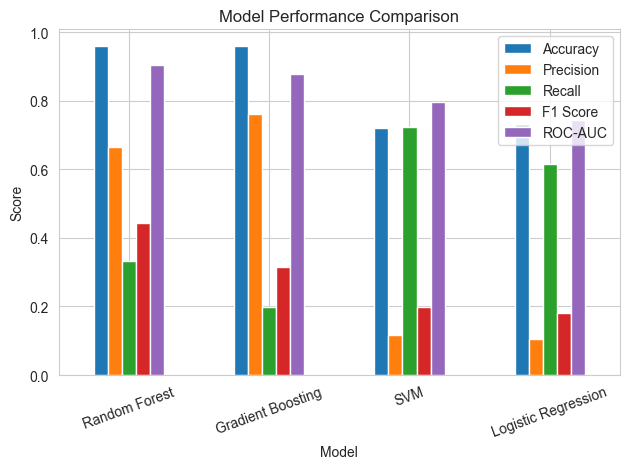

In [9]:
plt.figure(
    figsize=(12, 6)
)

results_df.set_index(
    "Model"
)[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].plot(
    kind="bar"
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

# Cross Validation

In [10]:
cv_results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results[name] = scores

    print(
        f"{name}: "
        f"{scores.mean():.4f} "
        f"(+/- {scores.std():.4f})"
    )

Logistic Regression: 0.7501 (+/- 0.0302)
Random Forest: 0.9106 (+/- 0.0176)
Gradient Boosting: 0.8896 (+/- 0.0185)
SVM: 0.7936 (+/- 0.0152)


# CV Visualization

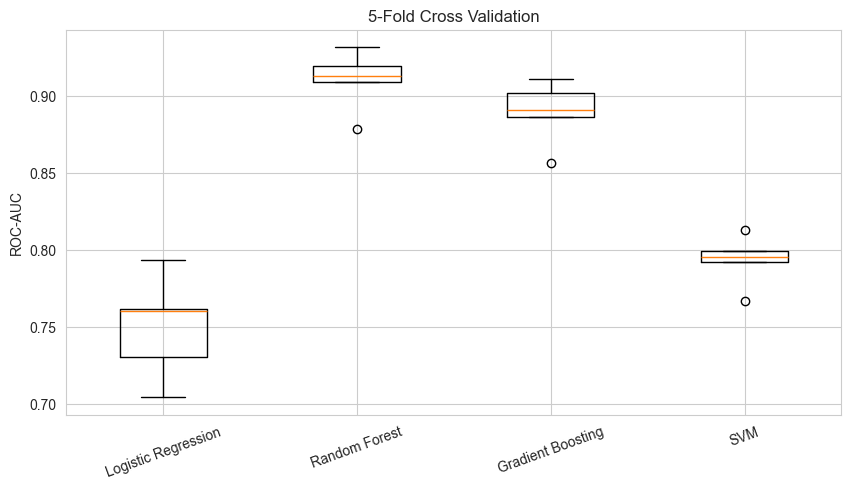

In [11]:
plt.figure(
    figsize=(10, 5)
)

plt.boxplot(
    cv_results.values(),
    tick_labels=cv_results.keys()
)

plt.ylabel(
    "ROC-AUC"
)

plt.title(
    "5-Fold Cross Validation"
)

plt.xticks(
    rotation=20
)

plt.show()

# ROC Curves

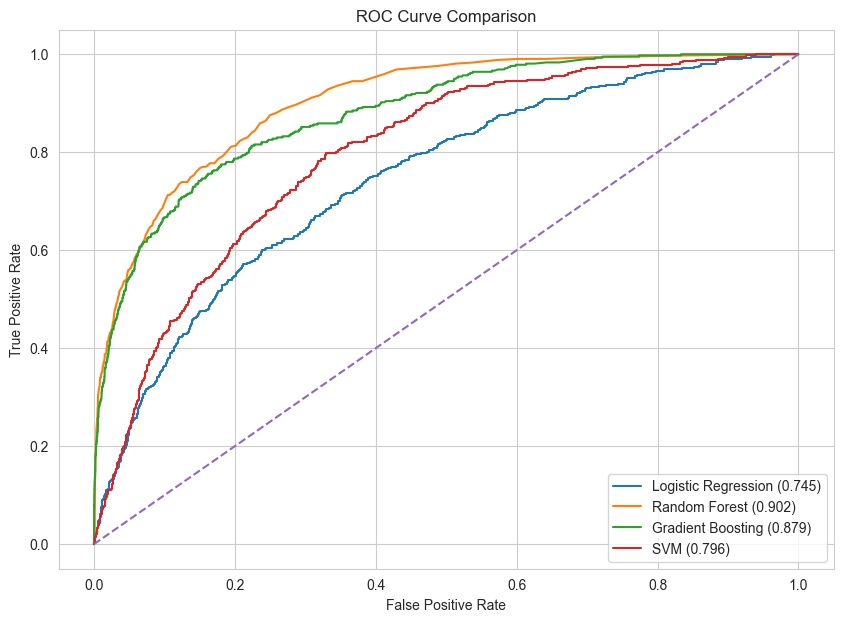

In [12]:
plt.figure(
    figsize=(10, 7)
)

for name, model in trained_models.items():

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} ({auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# Best Model

In [13]:
best_model_name = (
    results_df.iloc[0]["Model"]
)

print(
    "Best Model:",
    best_model_name
)

results_df

Best Model: Random Forest


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.959797,0.665072,0.332536,0.443381,0.902390
2,Gradient Boosting,0.958415,0.761468,0.198565,0.314991,0.878935
3,SVM,0.720194,0.115488,0.722488,0.199143,0.796406
0,Logistic Regression,0.730676,0.105588,0.614833,0.180224,0.744603


# Save Results

In [14]:
results_df.to_csv(
    "../data/model_results.csv",
    index=False
)

print(
    "Results saved."
)

Results saved.


In [15]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.959797,0.665072,0.332536,0.443381,0.902390
2,Gradient Boosting,0.958415,0.761468,0.198565,0.314991,0.878935
3,SVM,0.720194,0.115488,0.722488,0.199143,0.796406
0,Logistic Regression,0.730676,0.105588,0.614833,0.180224,0.744603


# Confusion Matrix for Best Model

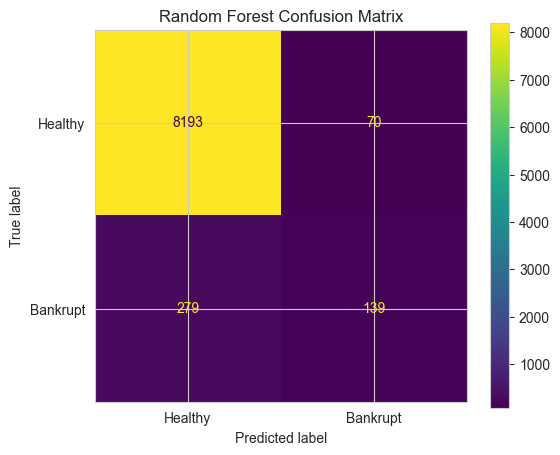

In [16]:
best_rf = trained_models["Random Forest"]

y_pred_rf = best_rf.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Healthy", "Bankrupt"],
    ax=ax
)

plt.title("Random Forest Confusion Matrix")

plt.show()

# Save Best Model

In [17]:
import joblib

joblib.dump(
    trained_models["Random Forest"],
    "../models/random_forest_baseline.pkl"
)

print("Model saved.")

Model saved.


# Classification Report

In [18]:
from sklearn.metrics import classification_report

y_pred_rf = trained_models["Random Forest"].predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Healthy",
            "Bankrupt"
        ]
    )
)

              precision    recall  f1-score   support

     Healthy       0.97      0.99      0.98      8263
    Bankrupt       0.67      0.33      0.44       418

    accuracy                           0.96      8681
   macro avg       0.82      0.66      0.71      8681
weighted avg       0.95      0.96      0.95      8681



In [ ]:
# Confusion Matrix

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Healthy",
        "Actual Bankrupt"
    ],
    columns=[
        "Predicted Healthy",
        "Predicted Bankrupt"
    ]
)

cm_df

,Predicted Healthy,Predicted Bankrupt
Actual Healthy,8193,70
Actual Bankrupt,279,139


# Interpretation

In [20]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_rf
).ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

True Negatives : 8193
False Positives: 70
False Negatives: 279
True Positives : 139
